# Exam summer 2026

In [12]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests


## 1 Real GDP across US states

### Question 1

#### 1.1.2 Common years and states

After keeping only the years available in both datasets and removing states with missing observations, we are left with 29 years and 50 states.


#### 1.1.4 Real GDP per person in the first and last year

In 1997, Delaware had the highest real GDP per person and Idaho the lowest. In 2025, New York had the highest and Mississippi the lowest.

The ratio between the highest and lowest increased slightly from 2.18 to 2.23, while the average real GDP per person increased from $44,592.95 to $64,674.46.


Number of years: 29
Number of states: 50
Year: 1997
Highest: DE, $69,748.74
Lowest: ID, $32,062.68
Ratio between highest and lowest: 2.18
Average: $44,592.95

Year: 2025
Highest: NY, $94,701.99
Lowest: MS, $42,434.03
Ratio between highest and lowest: 2.23
Average: $64,674.46



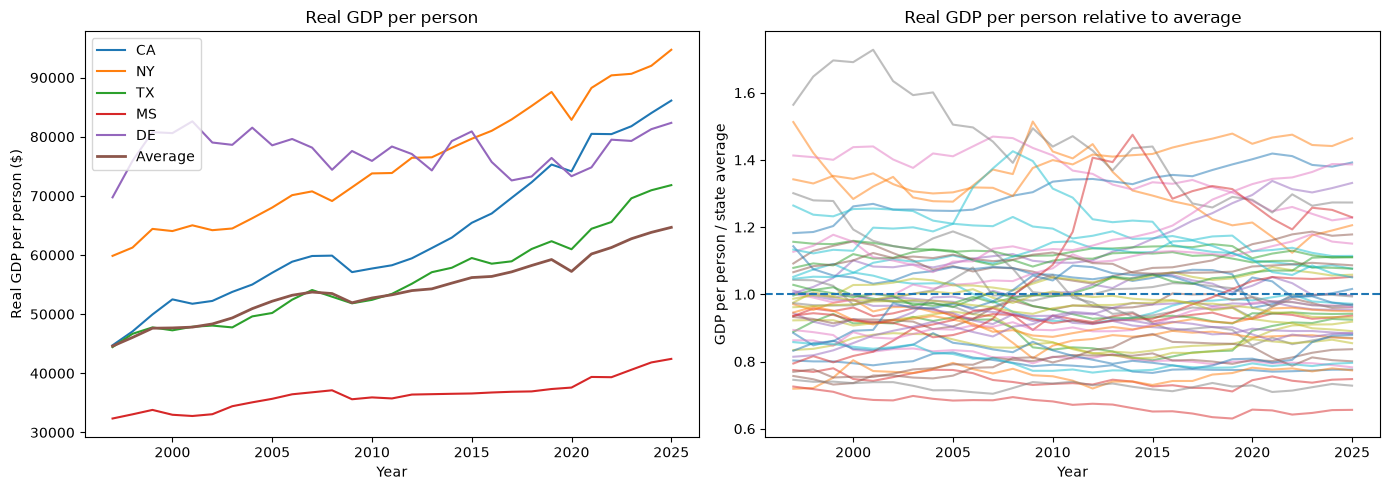

In [ ]:

# 1.1.1 Import state codes and regions
from states import STATES, REGION

# FRED API key
api_key = '9829eaf99bf0bb5da6b84dfcda3fb0e4'

# Function for downloading one series from FRED
def download_fred_series(series_id):

    # FRED API URL
    url = 'https://api.stlouisfed.org/fred/series/observations'

    # Information sent to FRED
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json'
    }

    # Download the data
    response = requests.get(url, params=params)
    response.raise_for_status()

    # Convert the data to a dataframe
    data = pd.DataFrame(response.json()['observations'])

    # Convert date to year
    data['year'] = pd.to_datetime(data['date']).dt.year

    # Convert values to numbers
    data['value'] = pd.to_numeric(
        data['value'],
        errors='coerce'
    )

    # Return a series with year as index
    return data.set_index('year')['value']


# Empty dataframes
gdp = pd.DataFrame()
pop = pd.DataFrame()

# Download GDP and population for all 50 states
for state in STATES:

    # Real GDP
    gdp[state] = download_fred_series(
        f'{state}RGSP'
    )

    # Population
    pop[state] = download_fred_series(
        f'{state}POP'
    )


# Check the dataframes
#display(gdp.head())
#display(pop.head())

#print("GDP shape:", gdp.shape)
#print("Population shape:", pop.shape)


# 1.1.2 Keep common years and remove states with missing observations

# Find the years that are in both dataframes
common_years = gdp.index.intersection(pop.index)

# Keep only the common years
gdp_common = gdp.loc[common_years].copy()
pop_common = pop.loc[common_years].copy()

# Find states with no missing values in either dataframe
valid_states = (
    gdp_common.notna().all()
    & pop_common.notna().all()
)

# Keep only states without missing observations
gdp = gdp_common.loc[:, valid_states]
pop = pop_common.loc[:, valid_states]

# Report number of years and states
print("Number of years:", len(gdp.index))
print("Number of states:", len(gdp.columns))


# 1.1.3 Compute real GDP per person in dollars

# GDP is in millions and population is in thousands
y = (gdp / pop) * 1000

# 1.1.4 Compare real GDP per person in the first and last year

# First and last year in the data
tfirst = y.index.min()
tlast = y.index.max()

# Loop over the first and last year
for year in [tfirst, tlast]:

    # GDP per person for all states in this year
    y_year = y.loc[year]

    # Highest and lowest state
    highest_state = y_year.idxmax()
    lowest_state = y_year.idxmin()

    # Highest and lowest GDP per person
    highest = y_year.max()
    lowest = y_year.min()

    # Ratio and average across states
    ratio = highest / lowest
    average = y_year.mean()

    # Report results
    print(f"Year: {year}")
    print(f"Highest: {highest_state}, ${highest:,.2f}")
    print(f"Lowest: {lowest_state}, ${lowest:,.2f}")
    print(f"Ratio between highest and lowest: {ratio:.2f}")
    print(f"Average: ${average:,.2f}")
    print()


# 1.1.5 Plot GDP per person and GDP relative to the state average

# Choosing a handful of states
chosen_states = ['CA', 'NY', 'TX', 'MS', 'DE']

# Average GDP per person across states in each year
y_average = y.mean(axis=1)

# GDP per person relative to the average in each year
y_relative = y.div(y_average, axis=0)

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: GDP per person for selected states
for state in chosen_states:
    axes[0].plot(y.index, y[state], label=state)

# Add average across all states
axes[0].plot(y.index, y_average, label='Average', linewidth=2)

axes[0].set_xlabel('Year')
axes[0].set_ylabel('Real GDP per person ($)')
axes[0].set_title('Real GDP per person')
axes[0].legend()

# Panel 2: GDP per person relative to the average
for state in y.columns:
    axes[1].plot(y.index, y_relative[state], alpha=0.5)

# A value of 1 corresponds to the state average
axes[1].axhline(1, linestyle='--')

axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP per person / state average')
axes[1].set_title('Real GDP per person relative to average')

plt.tight_layout()
plt.show()



### Question 2

#### 1.2.2 Dispersion in the first and last year

The standard deviation of log real GDP per person was 0.1833 in 1997 and 0.1786 in 2025.

The highest value was 0.1909 in 2012, while the lowest value was 0.1683 in 2005.


#### 1.2.3 Development in variation across states

The figure does not show a clear long-run trend. The variation in real GDP per person falls in the early 2000s, reaches its lowest point in 2005, and then increases again until the 2010s.

After the high values around 2012–2015, the variation generally falls again. Since the value in 2025 is slightly lower than in 1997, there is a small overall decline, but the development is not smooth enough to indicate a clear trend.

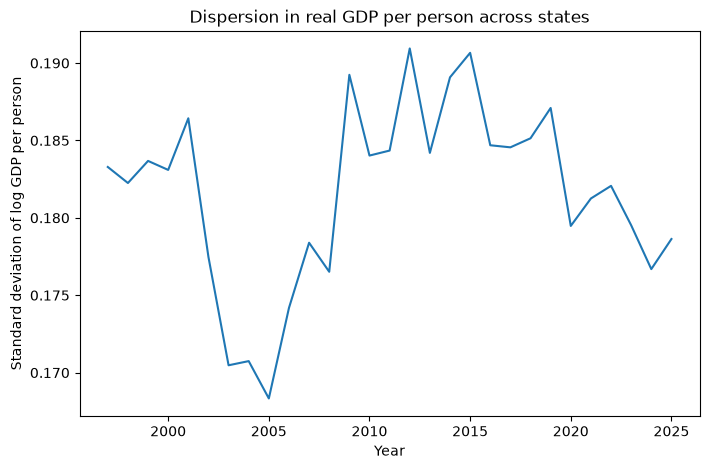

Standard deviation in 1997: 0.1833
Standard deviation in 2025: 0.1786
Highest standard deviation: 0.1909 in 2012
Lowest standard deviation: 0.1683 in 2005


In [14]:
# 1.2.1 Standard deviation of log real GDP per person

# Take the logarithm of GDP per person
log_y = np.log(y)

# Standard deviation across states for each year
std_log_y = log_y.std(axis=1)

# Plot the standard deviation over time
plt.figure(figsize=(8, 5))

plt.plot(std_log_y.index, std_log_y)

plt.xlabel('Year')
plt.ylabel('Standard deviation of log GDP per person')
plt.title('Dispersion in real GDP per person across states')

plt.show()

# 1.2.2 Report dispersion in the first and last year and its highest and lowest values

# First and last year
tfirst = std_log_y.index.min()
tlast = std_log_y.index.max()

# Year with highest and lowest standard deviation
year_highest = std_log_y.idxmax()
year_lowest = std_log_y.idxmin()

# Report results
print(f"Standard deviation in {tfirst}: {std_log_y.loc[tfirst]:.4f}")
print(f"Standard deviation in {tlast}: {std_log_y.loc[tlast]:.4f}")
print(f"Highest standard deviation: {std_log_y.loc[year_highest]:.4f} in {year_highest}")
print(f"Lowest standard deviation: {std_log_y.loc[year_lowest]:.4f} in {year_lowest}")


### Question 3


#### 1.3.2 Fitted line and correlation

Using `np.polyfit`, we obtain $a = 0.118089$ and $b = -0.009802$.

The fitted line is therefore

$$
g_i = 0.118089 - 0.009802 \log(y_{i,tfirst})
$$

The correlation between $g_i$ and $\log(y_{i,tfirst})$ is $-0.3886$.

#### 1.3.3 States with the highest and lowest growth rates

The five states with the highest average annual growth rates are North Dakota, California, Washington, Massachusetts and South Dakota.

The five states with the lowest average annual growth rates are Nevada, Alaska, Delaware, Louisiana and Connecticut.


#### 1.3.4 Speed of convergence and half-life

The annual speed of convergence is $\lambda = 0.0115$, and the half-life is 60.49 years.

This means that about 1.15% of the initial gap disappears each year, and it takes about 60.5 years for half of the initial gap to disappear.


#### 1.3.5 Description of the convergence figure

The figure shows a negative relationship between initial real GDP per person and average annual growth. States with lower initial GDP per person tend to have higher growth rates.

However, the points are quite spread out around the fitted line, so the relationship is not very strong. This is consistent with the correlation of -0.3886.

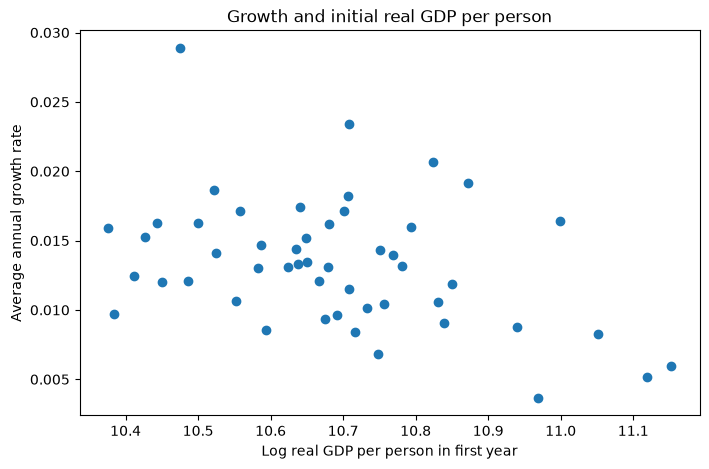

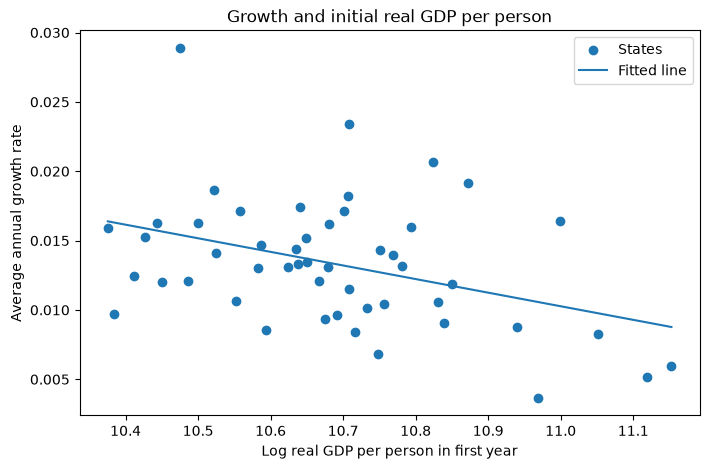

a = 0.118089
b = -0.009802
Correlation = -0.3886


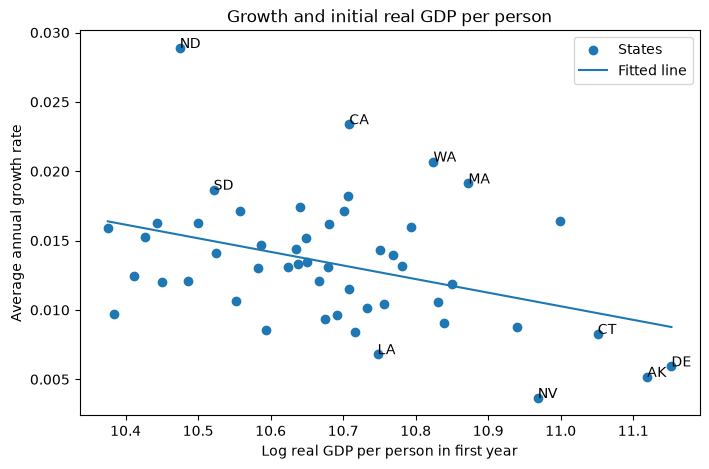

Lambda: 0.0115
Half-life: 60.49 years


In [ ]:
# 1.3.1 Scatter plot of growth against initial real GDP per person

# First and last year
tfirst = y.index.min()
tlast = y.index.max()
T = tlast - tfirst

# Log GDP per person in the first and last year
log_y_first = np.log(y.loc[tfirst])
log_y_last = np.log(y.loc[tlast])

# Average annual growth rate for each state
g = (log_y_last - log_y_first) / T

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g)

plt.xlabel('Log real GDP per person in first year')
plt.ylabel('Average annual growth rate')
plt.title('Growth and initial real GDP per person')

plt.show()


# 1.3.2 Fit a straight line and report coefficients and correlation

# Fit g = a + b*log(y_first)
b, a = np.polyfit(log_y_first, g, 1)

# Correlation between growth and initial GDP per person
correlation = np.corrcoef(log_y_first, g)[0, 1]

# Values for the fitted line
x_line = np.linspace(log_y_first.min(), log_y_first.max(), 100)
g_line = a + b * x_line

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g, label='States')

# Fitted line
plt.plot(x_line, g_line, label='Fitted line')

plt.xlabel('Log real GDP per person in first year')
plt.ylabel('Average annual growth rate')
plt.title('Growth and initial real GDP per person')
plt.legend()

plt.show()

# Report results
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"Correlation = {correlation:.4f}")


# 1.3.3 Add the five highest and five lowest growth states to the figure

# Find the five states with highest and lowest growth
highest_growth = g.nlargest(5).index
lowest_growth = g.nsmallest(5).index

# Making the figure again
plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g, label='States')
plt.plot(x_line, g_line, label='Fitted line')

# Add state names for the five highest growth rates
for state in highest_growth:
    plt.annotate(
        state,
        (log_y_first[state], g[state])
    )

# Add state names for the five lowest growth rates
for state in lowest_growth:
    plt.annotate(
        state,
        (log_y_first[state], g[state])
    )

plt.xlabel('Log real GDP per person in first year')
plt.ylabel('Average annual growth rate')
plt.title('Growth and initial real GDP per person')
plt.legend()

plt.show()


# 1.3.4 Compute the speed of convergence and half-life

# Number of years between first and last year
T = tlast - tfirst

# Annual speed of convergence
lambda_ = -np.log(1 + b * T) / T

# Half-life
h = np.log(2) / lambda_

# Report results
print(f"Lambda: {lambda_:.4f}")
print(f"Half-life: {h:.2f} years")





### Question 4

#### 1.4.1 Number of states by region

There are 16 states in the South, 13 in the West, 12 in the Midwest and 9 in the Northeast.

#### 1.4.3 Changes in relative GDP per person by region

From 1997 to 2025, the Midwest increased from 0.9683 to 1.0055, the Northeast increased from 1.0873 to 1.0952, the South decreased from 0.9513 to 0.9054, and the West increased from 1.0287 to 1.0454.

The South experienced the largest change, falling by 0.0459 relative to the overall state average.

South        16
West         13
Midwest      12
Northeast     9
Name: count, dtype: int64


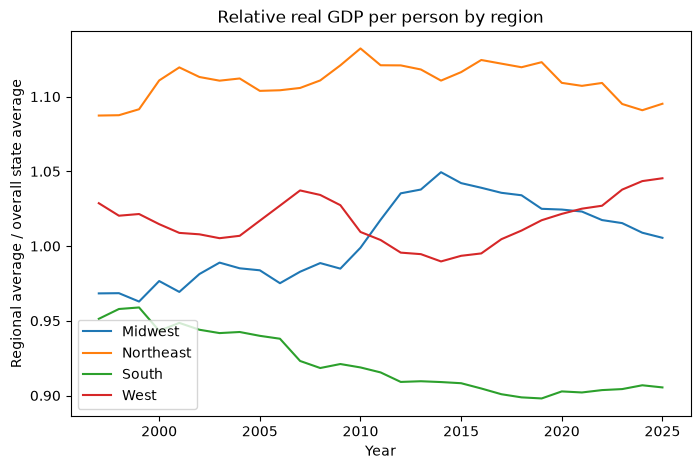

,First year,Last year,Change
Midwest,0.9683,1.0055,0.0372
Northeast,1.0873,1.0952,0.0079
South,0.9513,0.9054,-0.0459
West,1.0287,1.0454,0.0167


Largest movement: South
Change: -0.0459


In [23]:
# 1.4.1 Compute average relative GDP per person by region

# GDP per person relative to the average across all states
y_relative = y.div(y.mean(axis=1), axis=0)

# Group states by region and take the average within each region
region_relative = y_relative.T.groupby(REGION).mean().T

# Number of states in each region
region_counts = pd.Series(REGION).value_counts()

# Reporting number of states
print(region_counts)


# 1.4.2 Plot the four regional series over time

plt.figure(figsize=(8, 5))

# Plot one line for each region
for region in region_relative.columns:
    plt.plot(
        region_relative.index,
        region_relative[region],
        label=region
    )

plt.xlabel('Year')
plt.ylabel('Regional average / overall state average')
plt.title('Relative real GDP per person by region')
plt.legend()

plt.show()


# 1.4.3 Report regional values in the first and last year

# First and last year
tfirst = region_relative.index.min()
tlast = region_relative.index.max()

# Values in first and last year
first_values = region_relative.loc[tfirst]
last_values = region_relative.loc[tlast]

# Change over the period
change = last_values - first_values

# Collect results in a table
region_table = pd.DataFrame({
    'First year': first_values,
    'Last year': last_values,
    'Change': change
})

display(region_table.round(4))

# Region with the largest absolute change
largest_move = change.abs().idxmax()

print(f"Largest movement: {largest_move}")
print(f"Change: {change[largest_move]:.4f}")